# Homework 5 Solution

In [1]:
import os

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("dark_background")
sns.set_palette("husl")
plt.rcParams.update(
    {
        "figure.facecolor": "#111111",
        "axes.facecolor": "#111111",
        "axes.edgecolor": "#aaaaaa",
        "text.color": "#ffffff",
        "xtick.color": "#aaaaaa",
        "ytick.color": "#aaaaaa",
    }
)

os.makedirs("./figures", exist_ok=True)

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

## Problem 1

In [3]:
np.random.seed(42)
mean = [0, 0, 0]
cov = [[1, 0.9, 0.7], [0.9, 1, 0.8], [0.7, 0.8, 1]]
X = np.random.multivariate_normal(mean, cov, 500)

### 1.1

The covariance matrix is symmetric, so use `np.linalg.eigh`: it returns real
eigenvalues in ascending order. `np.linalg.eig` is the general routine and returns
complex dtype in no particular order.

In [4]:
X_demeaned = X - X.mean(axis=0)
covX = 1 / 499 * X_demeaned.T @ X_demeaned

eigenvalues, eigenvectors = np.linalg.eigh(covX)
order = np.argsort(eigenvalues)[::-1]
eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]

print("Eigenvalues:", np.round(eigenvalues, 6))
print("Explained variance ratio:", np.round(eigenvalues / eigenvalues.sum(), 4))
print("Eigenvectors (columns):")
print(np.round(eigenvectors, 6))

Eigenvalues: [2.290778 0.313006 0.087826]
Explained variance ratio: [0.8511 0.1163 0.0326]
Eigenvectors (columns):
[[-0.58599  -0.571257 -0.574701]
 [-0.604994 -0.163388  0.779286]
 [-0.539071  0.804345 -0.249863]]


### 1.2

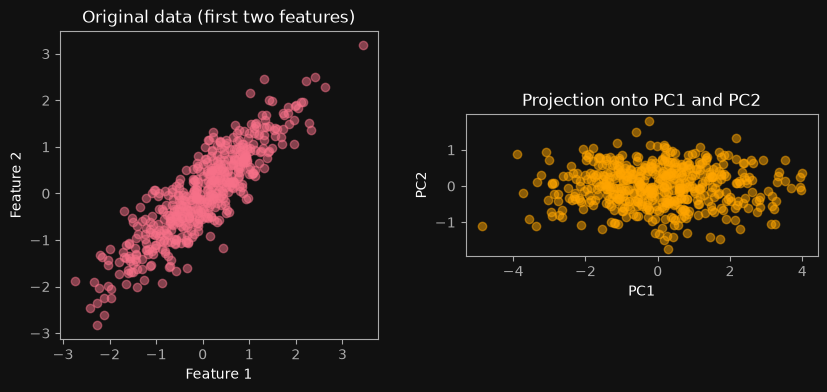

In [5]:
X_pca = X_demeaned @ eigenvectors[:, :2]

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(X_demeaned[:, 0], X_demeaned[:, 1], alpha=0.5)
ax[0].set_title("Original data (first two features)")
ax[0].set_xlabel("Feature 1")
ax[0].set_ylabel("Feature 2")
ax[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5, color="orange")
ax[1].set_title("Projection onto PC1 and PC2")
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")
for a in ax:
    a.set_aspect("equal")
fig.savefig("./figures/problem1_pca_projection.png", dpi=300, bbox_inches="tight")

### 1.3

In [6]:
pca = PCA().fit(X)

print("manual eigenvalues: ", np.round(eigenvalues, 6))
print("sklearn variances:  ", np.round(pca.explained_variance_, 6))
print("max abs difference: ", np.abs(eigenvalues - pca.explained_variance_).max())
print()
print("manual eigenvectors (rows):")
print(np.round(eigenvectors.T, 6))
print("sklearn components_:")
print(np.round(pca.components_, 6))
print()
print("equal up to a sign flip per component:")
print(np.allclose(np.abs(eigenvectors.T), np.abs(pca.components_)))

manual eigenvalues:  [2.290778 0.313006 0.087826]
sklearn variances:   [2.290778 0.313006 0.087826]
max abs difference:  4.440892098500626e-16

manual eigenvectors (rows):
[[-0.58599  -0.604994 -0.539071]
 [-0.571257 -0.163388  0.804345]
 [-0.574701  0.779286 -0.249863]]
sklearn components_:
[[ 0.58599   0.604994  0.539071]
 [-0.571257 -0.163388  0.804345]
 [-0.574701  0.779286 -0.249863]]

equal up to a sign flip per component:
True


## Problem 2

In [7]:
np.random.seed(42)
n = 500

X_high_var = np.random.normal(0, 10, (n, 7))
X_low_var = np.random.normal(0, 1, (n, 3))
X = np.hstack([X_high_var, X_low_var])

true_beta = np.array([0] * 7 + [2, -2, 2])
y = X @ true_beta + np.random.normal(0, 0.5, n)

### 2.1

In [8]:
pca = PCA().fit(X)  # PCA centers the data itself
scores = pca.transform(X)

print(
    pd.Series(
        pca.explained_variance_ratio_, index=[f"PC{i}" for i in range(1, 11)], name="ratio"
    ).to_latex(float_format="{:0.5f}".format)
)
print(f"first 7 components: {pca.explained_variance_ratio_[:7].sum():.4f} of the variance")
print(f"last 3 components:  {pca.explained_variance_ratio_[7:].sum():.4f} of the variance")

\begin{tabular}{lr}
\toprule
 & ratio \\
\midrule
PC1 & 0.16773 \\
PC2 & 0.16159 \\
PC3 & 0.15787 \\
PC4 & 0.14255 \\
PC5 & 0.12969 \\
PC6 & 0.12647 \\
PC7 & 0.10983 \\
PC8 & 0.00149 \\
PC9 & 0.00142 \\
PC10 & 0.00136 \\
\bottomrule
\end{tabular}

first 7 components: 0.9957 of the variance
last 3 components:  0.0043 of the variance


### 2.2

In [9]:
model_high = sm.OLS(y, sm.add_constant(scores[:, :7])).fit()
print(f"R^2 using PC1-PC7:  {model_high.rsquared:.4f}")

R^2 using PC1-PC7:  0.0064


### 2.3

In [10]:
model_low = sm.OLS(y, sm.add_constant(scores[:, 7:])).fit()
print(f"R^2 using PC8-PC10: {model_low.rsquared:.4f}")

R^2 using PC8-PC10: 0.9750


### 2.4

Written answer only; see the write-up.

## Problem 3

In [11]:
np.random.seed(42)
n_points = 500
grid_size = 4
limit = 10
step = (limit * 2) / grid_size

all_points = []
all_labels = []

for i in range(grid_size):
    for j in range(grid_size):
        label = (i + j) % 2
        x_min, x_max = -limit + i * step, -limit + (i + 1) * step
        y_min, y_max = -limit + j * step, -limit + (j + 1) * step
        points_x = np.random.uniform(x_min, x_max, int(n_points / 16))
        points_y = np.random.uniform(y_min, y_max, int(n_points / 16))
        all_points.append(np.vstack((points_x, points_y)).T)
        all_labels.extend([label] * int(n_points / 16))

X = np.vstack(all_points)
y = np.array(all_labels)
print(X.shape)

(496, 2)


### 3.1, 3.2

In [12]:
class BaggingDTC:
    def __init__(self, B=100, max_depth=5, seed=0):
        self.B = B
        self.max_depth = max_depth
        self.rng = np.random.RandomState(seed)
        self.trees = []

    def fit(self, X, y):
        n_samples = X.shape[0]
        for _ in range(self.B):
            idx = self.rng.choice(n_samples, size=n_samples, replace=True)
            tree = DecisionTreeClassifier(max_depth=self.max_depth, random_state=42)
            self.trees.append(tree.fit(X[idx], y[idx]))
        return self

    def predict(self, X):
        votes = np.array([tree.predict(X) for tree in self.trees])
        return (votes.mean(axis=0) >= 0.5).astype(int)

single tree training accuracy: 1.0000
bagging training accuracy:     0.9194


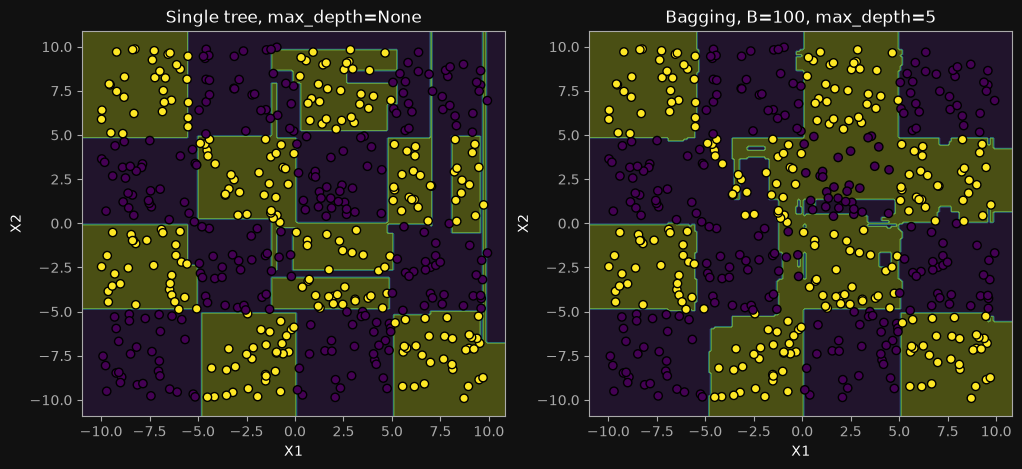

In [13]:
dtc = DecisionTreeClassifier(max_depth=None, random_state=42).fit(X, y)
dtc_bag = BaggingDTC(B=100).fit(X, y)


def plot_decision_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k")
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_title(title)


fig, ax = plt.subplots(1, 2, figsize=(12, 5))
plot_decision_boundary(dtc, X, y, ax[0], "Single tree, max_depth=None")
plot_decision_boundary(dtc_bag, X, y, ax[1], "Bagging, B=100, max_depth=5")
fig.savefig("./figures/problem3_bagging_comparison.png", dpi=300, bbox_inches="tight")

print(f"single tree training accuracy: {np.mean(dtc.predict(X) == y):.4f}")
print(f"bagging training accuracy:     {np.mean(dtc_bag.predict(X) == y):.4f}")

### 3.3

Written answer only; see the write-up.

## Problem 4

In [14]:
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = np.exp(X.ravel() / 3) + np.random.normal(0, 0.5, 100)

### 4.1

OLS MSE: 8.2298


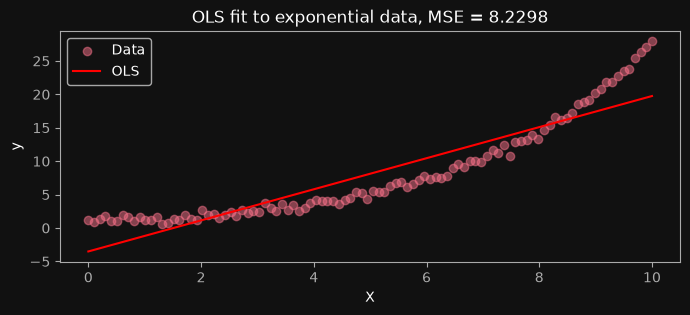

In [15]:
ols = sm.OLS(y, sm.add_constant(X)).fit()
mse_ols = np.mean(ols.resid**2)
print(f"OLS MSE: {mse_ols:.4f}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.scatter(X, y, label="Data", alpha=0.5)
ax.plot(X, ols.fittedvalues, color="red", label="OLS")
ax.set_title(f"OLS fit to exponential data, MSE = {mse_ols:.4f}")
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.legend()
fig.savefig("./figures/problem4_ols_fit.png", dpi=300, bbox_inches="tight")

### 4.2

In [16]:
pred = ols.fittedvalues.copy()
eta = 0.1
for _ in range(50):
    resid_m = y - pred
    tree = DecisionTreeRegressor(max_depth=1, random_state=0).fit(X, resid_m)
    pred = pred + eta * tree.predict(X)

### 4.3

OLS MSE:     8.2298
Boosted MSE: 0.7754
ratio:       10.61x


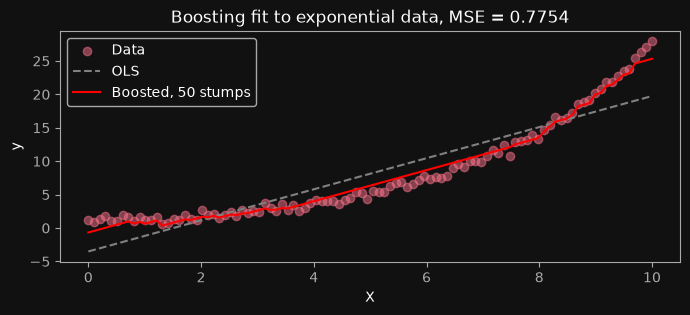

In [17]:
mse_boost = np.mean((y - pred) ** 2)
print(f"OLS MSE:     {mse_ols:.4f}")
print(f"Boosted MSE: {mse_boost:.4f}")
print(f"ratio:       {mse_ols / mse_boost:.2f}x")

fig, ax = plt.subplots(figsize=(8, 3))
ax.scatter(X, y, label="Data", alpha=0.5)
ax.plot(X, ols.fittedvalues, color="grey", ls="--", label="OLS")
ax.plot(X, pred, color="red", label="Boosted, 50 stumps")
ax.set_title(f"Boosting fit to exponential data, MSE = {mse_boost:.4f}")
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.legend()
fig.savefig("./figures/problem4_boosting_fit.png", dpi=300, bbox_inches="tight")

## Problem 5

In [18]:
np.random.seed(42)
n_points = 500
grid_size = 4
limit = 10
step = (limit * 2) / grid_size

all_points = []
all_labels = []

for i in range(grid_size):
    for j in range(grid_size):
        label = (i + j) % 2
        x_min, x_max = -limit + i * step, -limit + (i + 1) * step
        y_min, y_max = -limit + j * step, -limit + (j + 1) * step
        points_x = np.random.uniform(x_min, x_max, int(n_points / 16))
        points_y = np.random.uniform(y_min, y_max, int(n_points / 16))
        all_points.append(np.vstack((points_x, points_y)).T)
        all_labels.extend([label] * int(n_points / 16))

X = np.vstack(all_points)
y = np.array(all_labels)

### 5.1

In [19]:
def make_models():
    return {
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "AdaBoost": AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=3),
            n_estimators=50,
            learning_rate=1.0,
            random_state=42,
        ),
    }


# As asked: fit on the whole dataset and report accuracy on it.
in_sample = {name: m.fit(X, y).score(X, y) for name, m in make_models().items()}

# Held out, because the line above cannot separate the two models.
rng = np.random.RandomState(42)
train_ind = rng.choice(len(X), size=int(len(X) * 0.7), replace=False)
mask = np.zeros(len(X), dtype=bool)
mask[train_ind] = True
held_out = {
    name: m.fit(X[mask], y[mask]).score(X[~mask], y[~mask])
    for name, m in make_models().items()
}

print(
    pd.DataFrame({"in-sample": in_sample, "held out (70/30)": held_out}).to_latex(
        float_format="{:0.4f}".format
    )
)
print(f"n = {len(y)}, train = {mask.sum()}, test = {(~mask).sum()}")

\begin{tabular}{lrr}
\toprule
 & in-sample & held out (70/30) \\
\midrule
Random Forest & 1.0000 & 0.8792 \\
AdaBoost & 1.0000 & 0.8389 \\
\bottomrule
\end{tabular}

n = 496, train = 347, test = 149


### 5.2

Written answer only; see the write-up.

## Problem 6

In [20]:
np.random.seed(42)
X_moons, _ = make_moons(n_samples=300, noise=0.05)

### 6.1

In [21]:
def cdist(a, b):
    return np.sqrt(((a[:, np.newaxis, :] - b[np.newaxis, :, :]) ** 2).sum(axis=2))


eps = 0.2
min_pts = 5
labels = np.full(X_moons.shape[0], -2)  # -2: unvisited, -1: noise
cluster_id = -1
dists = cdist(X_moons, X_moons)

for i in range(len(X_moons)):
    if labels[i] != -2:
        continue
    neighbors = np.where(dists[i] < eps)[0]
    if len(neighbors) < min_pts:
        labels[i] = -1  # noise, but may still be claimed as a border point below
    else:
        cluster_id += 1
        labels[i] = cluster_id
        queue = list(neighbors)
        while queue:
            q = queue.pop(0)
            if labels[q] >= 0:
                continue  # already in a cluster
            labels[q] = cluster_id  # unvisited, or previously marked noise
            q_neighbors = np.where(dists[q] < eps)[0]
            if len(q_neighbors) >= min_pts:
                queue.extend(q_neighbors)

print("labels found:", dict(zip(*[a.tolist() for a in np.unique(labels, return_counts=True)])))

labels found: {0: 150, 1: 150}


### 6.2

sklearn labels: {0: 150, 1: 150}
identical labelling: True


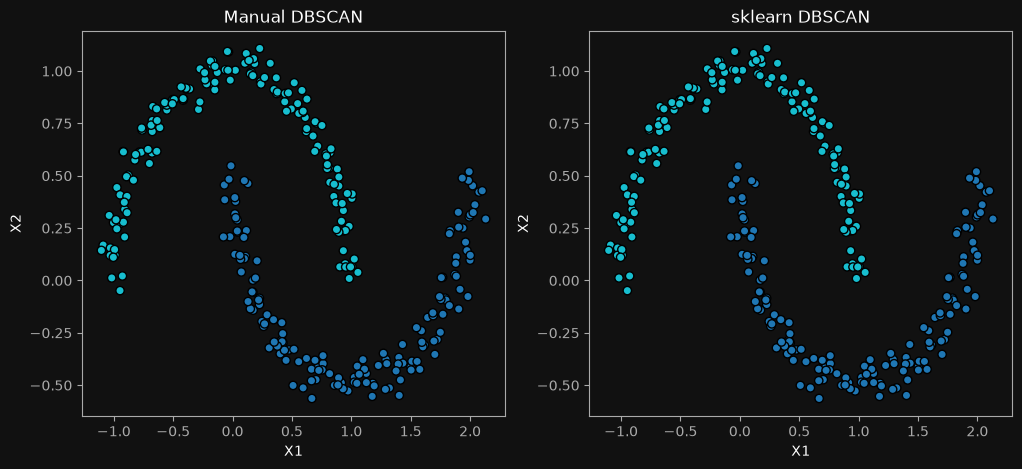

In [22]:
labels_sklearn = DBSCAN(eps=0.2, min_samples=5).fit(X_moons).labels_

print("sklearn labels:", dict(zip(*[a.tolist() for a in np.unique(labels_sklearn, return_counts=True)])))
print("identical labelling:", bool(np.array_equal(labels, labels_sklearn)))

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, lab, title in zip(ax, [labels, labels_sklearn], ["Manual DBSCAN", "sklearn DBSCAN"]):
    a.scatter(X_moons[:, 0], X_moons[:, 1], c=lab, cmap="tab10", edgecolors="k")
    a.set_xlabel("X1")
    a.set_ylabel("X2")
    a.set_title(title)
fig.savefig("./figures/problem6_dbscan_comparison.png", dpi=300, bbox_inches="tight")